# Topographic Positioning Index Methods

---

## Overview

This notebook demonstrates an open-source implementation of the Topographic Position Index (TPI) for identifying bathymetric features from gridded seabed data. TPI compares the depth of each cell to the average depth of its surrounding neighbourhood, making it possible to identify bathymetric highs and lows relative to the local seafloor. These features are then extracted, converted into polygons, and filtered to create maps that can be used for geomorphic and spatial analysis.

By the end of this notebook, you will understand:

1. How bathymetry data are read, visualized, and prepared for analysis.
2. How the Topographic Position Index (TPI) is calculated from a bathymetric raster.
3. How statistical thresholds are used to identify bathymetric high and low features.
4. How raster feature masks are converted into polygons through polygonization.
5. How area filtering can be used to remove small features and reduce noise.

## Prerequisites

This notebook assumes a basic understanding of Python and geospatial data. No prior knowledge of TPI is required, as the concepts and calculations are introduced throughout the notebook.

| Concept | Importance | Notes |
|----------|----------|----------|
| Python programming | Necessary | Basic familiarity with variables, arrays, and plotting. |
| Raster data | Necessary | Understanding that data are stored as a grid of cells. |
| Bathymetry | Helpful | Basic understanding of seafloor depth data. |
| GIS concepts | Helpful | Familiarity with rasters, polygons, and coordinate systems. |

**Estimated time to complete:** 30 minutes

---

# Imports

In [1]:
from pathlib import Path                          # File paths

import numpy as np                                # Array operations

import os                                         # builds file paths 

import matplotlib.pyplot as plt                   # Plotting
from mpl_toolkits.axes_grid1 import make_axes_locatable  # Colorbars
import matplotlib.ticker as mticker              # Axis formatting

import rasterio as rio                            # Raster I/O
from rasterio.plot import plotting_extent         # Raster extent

from scipy.ndimage import generic_filter          # Moving-window analysis

import rasterio.features as rfeatures             # Polygonization

from shapely.geometry import shape                # Geometry conversion

import geopandas as gpd                           # Vector data

formatter = mticker.FuncFormatter(
    lambda x, pos: f"{int(x):,}"
)

# Calculating TPI
First, we load the bathymetry raster into a NumPy array.

Any No Data values are converted to NaN so they can be ignored during calculations. We also extract information about the raster's coordinate system and cell size for later use.

In [2]:
# Read in data
def load_raster(path):
    with rio.open(path) as src:
        arr = src.read(1, masked=True).astype(float).filled(np.nan)
        return arr, src.transform, src.crs


bathy_path = Path("../data/gifford_bathy.tif")

bathy, transform, crs = load_raster(bathy_path)
extent = plotting_extent(bathy, transform)

dx = abs(transform.a)
dy = abs(transform.e)

print("shape:", bathy.shape)
print("crs:", crs)
print("resolution:", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))

shape: (835, 914)
crs: EPSG:32757
resolution: (50.0, 50.0)
depth range: (np.float64(-3221.864990234375), np.float64(-255.59681701660156))


## Define a Function to Calculate TPI
TPI is computed as the difference between the bathymetry value at a center cell and the mean bathymetry within a circular neighborhood.

$$
TPI_{x,y} = E_{x,y} - WD_{x,y}
$$

where:

- $E_{x,y}$ is the bathymetry value at the center cell
- $WD_{x,y}$ is the mean bathymetry within a circular neighborhood

The neighborhood size is controlled by the **TPI Circle Radius** parameter, expressed in raster cells.

After calculating the TPI raster, the spatial mean and standard deviation are used to define thresholds for identifying bathymetric highs and lows.

The function below implements the TPI raster calculation described in Step 1 of the workflow.

In [3]:
def calculate_tpi(bathy, radius_cells):

    # Create a circular neighbourhood footprint
    y, x = np.ogrid[
        -radius_cells:radius_cells + 1,
        -radius_cells:radius_cells + 1
    ]

    footprint = (x**2 + y**2) <= radius_cells**2

    # Compute TPI for each cell
    def tpi_filter(values):

        center = values[len(values)//2]

        if np.isnan(center):
            return np.nan

        return center - np.nanmean(values)

    # Apply moving-window calculation across the raster
    tpi = generic_filter(
        bathy,
        tpi_filter,
        footprint=footprint,
        mode="nearest"
    )

    # Return TPI raster and summary statistics
    return tpi, np.nanmean(tpi), np.nanstd(tpi)

### How the Function Works

For each cell in the raster, the function:

1. Creates a circular neighborhood around the cell.
2. Calculates the mean bathymetry within that neighborhood.
3. Subtracts the neighborhood mean from the center-cell bathymetry.
4. Stores the result as a TPI value.

The output is a new raster where each cell describes its relative position compared to its surroundings.

## Calculating TPI Thresholds
Once the TPI raster has been calculated, we can identify potential bathymetric highs and lows using threshold values. These thresholds are based on the mean and standard deviation of all TPI values in the raster.

In [4]:
def calculate_tpi_thresholds(tpi_mean, tpi_std, std_scale=1.0):

    high = tpi_mean + std_scale * tpi_std
    low = tpi_mean - std_scale * tpi_std

    return high, low

## Visualizing TPI at Multiple Scales

Using the TPI equation introduced in the previous section, TPI is calculated for several neighbourhood radii. The radius controls the scale of analysis: smaller radii emphasize local bathymetric variation, while larger radii highlight broader seabed features. A common rule of thumb is to choose a radius slightly larger than the feature size of interest.

To demonstrate this effect, TPI is calculated using three different radius values and the resulting rasters are compared below.

In [5]:
# Step 1: Create a loop to calculate TPI at various radii and store in a dictionary
radius_values = [5, 10, 25]

tpi_results = {}

for r in radius_values:

    tpi, mean, std = calculate_tpi(bathy, r)
    high, low = calculate_tpi_thresholds(mean, std)

    tpi_results[r] = {
        "tpi": tpi,
        "mean": mean,
        "std": std,
        "high": high,
        "low": low
    }

    print(f"Radius {r}: mean={mean:.3f}, std={std:.3f}")

Radius 5: mean=-0.008, std=10.611
Radius 10: mean=-0.030, std=17.356
Radius 25: mean=-0.236, std=37.611


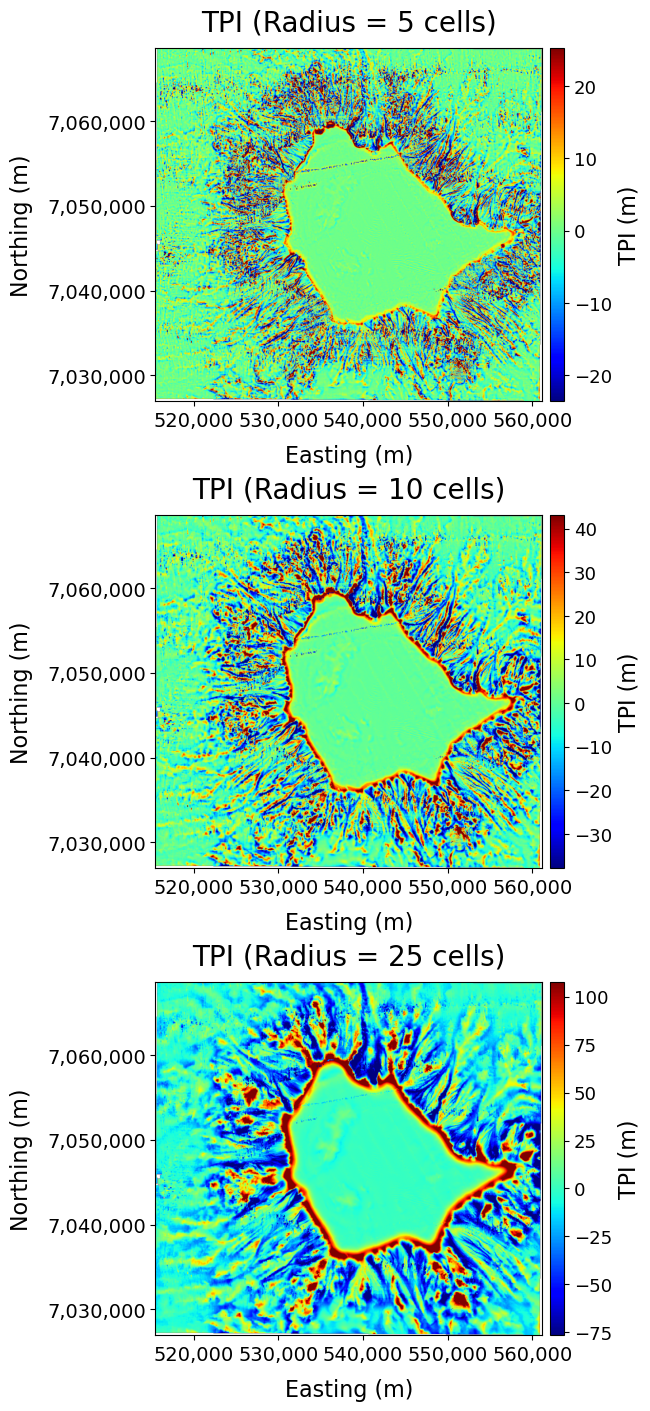

In [6]:
# Compare TPI rasters at multiple scales
# --------------------------------------
# Each subplot shows TPI calculated using a different
# neighbourhood radius. This allows the influence of
# radius selection on feature detection to be visualized.

fig, axes = plt.subplots(
    len(radius_values),
    1,
    figsize=(14, 14),
    constrained_layout=True
)

# Ensure axes is iterable if only one radius is used
if len(radius_values) == 1:
    axes = [axes]

# Loop through each radius and corresponding subplot
for ax, r in zip(axes, radius_values):

    # Retrieve the TPI raster for the current radius
    tpi = tpi_results[r]["tpi"]

    # Stretch the colour scale to improve contrast
    # and highlight variation within each raster
    vmin = np.nanpercentile(tpi, 2)
    vmax = np.nanpercentile(tpi, 98)

    # Display TPI raster
    im = ax.imshow(
        tpi,
        extent=extent,
        origin="upper",
        cmap="jet",
        vmin=vmin,
        vmax=vmax
    )

    # Add plot title showing neighbourhood size
    ax.set_title(
        f"TPI (Radius = {r} cells)",
        fontsize=20,
        pad=12
    )

    # Label map coordinates
    ax.set_xlabel(
        "Easting (m)",
        fontsize=16,
        labelpad=10
    )

    ax.set_ylabel(
        "Northing (m)",
        fontsize=16,
        labelpad=10
    )

    # Format axes for readability
    ax.tick_params(
        axis="both",
        labelsize=14
    )

    ax.locator_params(nbins=6)

    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    # Add a separate colourbar for each TPI raster
    divider = make_axes_locatable(ax)

    cax = divider.append_axes(
        "right",
        size="3.5%",
        pad=0.08
    )

    cbar = fig.colorbar(
        im,
        cax=cax
    )

    cbar.set_label(
        "TPI (m)",
        fontsize=16
    )

    cbar.ax.tick_params(
        labelsize=13
    )

# Display completed figure
plt.show()

The maps below illustrate how neighbourhood size influences the resulting TPI raster. Comparing multiple radii can help identify the scale that best captures the bathymetric features of interest.

---

# Area Thresholding
After selecting a TPI radius, statistical thresholds can be applied to isolate the most significant bathymetric highs and lows. This process removes weak deviations from the local mean and focuses the analysis on features that are more likely to represent meaningful seabed morphology.

For this demonstration, a radius of 25 cells is used.

In [7]:
# Select radius for threshold demonstration
# -----------------------------------------
# The 25-cell radius is used to illustrate how
# thresholding extracts significant features.

r = 25

tpi = tpi_results[r]["tpi"]
tpi_mean = tpi_results[r]["mean"]
tpi_std = tpi_results[r]["std"]

high_thresh = tpi_results[r]["high"]
low_thresh = tpi_results[r]["low"]

## Raw TPI Signal

Before thresholding, positive and negative TPI values represent all bathymetric highs and lows relative to the local neighbourhood.

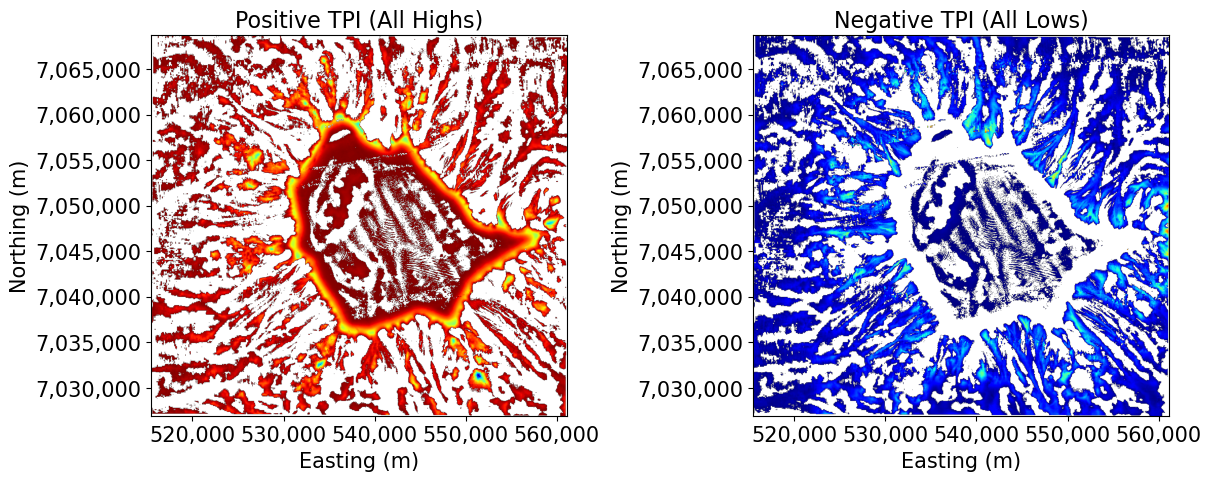

In [8]:
# Separate positive and negative TPI values
# -----------------------------------------
# Positive values indicate bathymetric highs,
# while negative values indicate bathymetric lows.

tpi_pos = np.where(tpi > 0, tpi, np.nan)
tpi_neg = np.where(tpi < 0, tpi, np.nan)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 8),
    constrained_layout=True
)

# Plot positive TPI values
im0 = axes[0].imshow(
    tpi_pos,
    extent=extent,
    origin="upper",
    cmap="jet_r"
)

axes[0].set_title(
    "Positive TPI (All Highs)",
    fontsize=16
)

# Plot negative TPI values
im1 = axes[1].imshow(
    tpi_neg,
    extent=extent,
    origin="upper",
    cmap="jet_r"
)

axes[1].set_title(
    "Negative TPI (All Lows)",
    fontsize=16
)

# Format axes
for ax in axes:

    ax.set_xlabel("Easting (m)", fontsize=15)
    ax.set_ylabel("Northing (m)", fontsize=15)

    ax.tick_params(labelsize=15)

    ax.ticklabel_format(
        style="plain",
        useOffset=False
    )

    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

plt.show()

## Thresholded Features

The thresholds calculated from the TPI mean and standard deviation are used to isolate the strongest positive and negative anomalies.

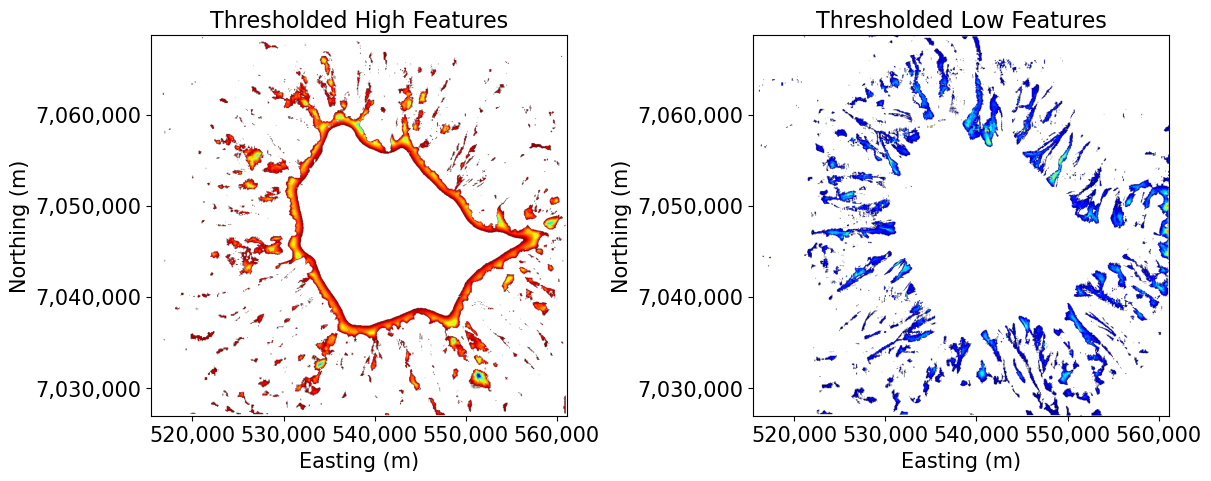

In [9]:
# Apply high and low TPI thresholds
# Only cells exceeding the statistical thresholds are retained as candidate bathymetric features.

tpi_high = np.where(
    tpi > high_thresh,
    tpi,
    np.nan
)

tpi_low = np.where(
    tpi < low_thresh,
    tpi,
    np.nan
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 8),
    constrained_layout=True
)

# Thresholded high features
axes[0].imshow(
    tpi_high,
    extent=extent,
    origin="upper",
    cmap="jet_r"
)

axes[0].set_title(
    "Thresholded High Features",
    fontsize=16
)

# Thresholded low features
axes[1].imshow(
    tpi_low,
    extent=extent,
    origin="upper",
    cmap="jet_r"
)

axes[1].set_title(
    "Thresholded Low Features",
    fontsize=16
)

# Format axes
for ax in axes:

    ax.set_xlabel("Easting (m)", fontsize=15)
    ax.set_ylabel("Northing (m)", fontsize=15)

    ax.tick_params(labelsize=15)

    ax.ticklabel_format(
        style="plain",
        useOffset=False
    )

    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    ax.locator_params(nbins=5)

plt.show()

### Interpretation

The raw TPI raster contains all bathymetric variation relative to the local neighbourhood. Thresholding removes weaker anomalies and retains only the strongest bathymetric highs and lows. Together, radius selection and thresholding control the scale and sensitivity of feature detection, helping distinguish meaningful geomorphic features from background variation.

---

# Polygonization

## Create Threshold Masks

Polygonization requires specific regions rather than continuous TPI values. Following the method described in the paper, cells are classified using thresholds derived from the mean and standard deviation of the TPI raster.

For bathymetric highs:

$$
\text{TPI}_{T}
=
\text{TPI}_{m}
+
C_{\text{TPI}}
\times
\text{TPI}_{s}
$$

where:

- $\text{TPI}_{m}$ = mean TPI value
- $\text{TPI}_{s}$ = standard deviation of TPI values
- $C_{\text{TPI}}$ = user-defined scaling parameter

Cells with TPI values greater than this threshold are classified as candidate bathymetric high features and form the binary mask used for polygonization.

In [10]:
# Create binary masks from thresholded TPI values
finite_tpi = np.isfinite(tpi)

mask_high = finite_tpi & (tpi > high_thresh)
mask_low = finite_tpi & (tpi < low_thresh)

print("High candidate pixels:", int(mask_high.sum()))
print("Low candidate pixels:", int(mask_low.sum()))

High candidate pixels: 76959
Low candidate pixels: 81620


## Visualize Threshold TPI and Mask

The threshold mask is the direct input to the polygonization step. White pixels represent cells classified as bathymetric features, while black pixels represent background cells.

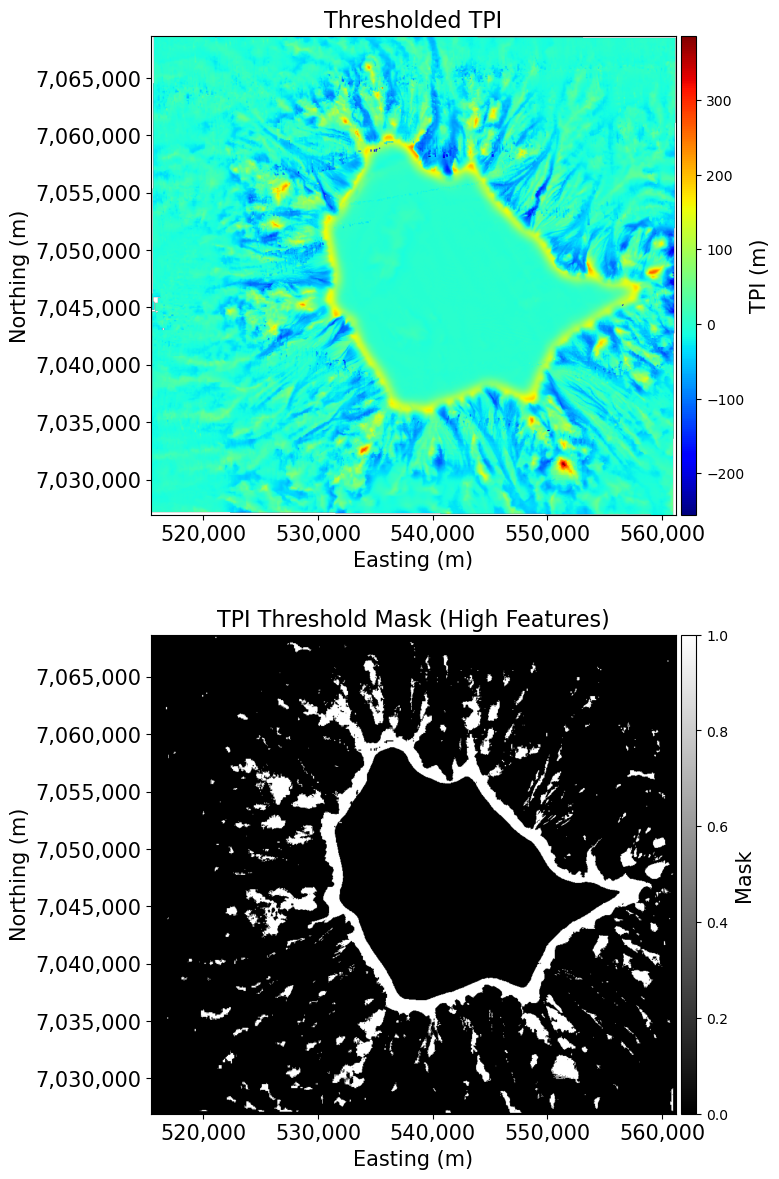

In [11]:
# Create vertically stacked subplots (High Features)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))
plt.subplots_adjust(hspace=0.25)  # controls spacing between panels

# TOP PANEL: TPI raster
im1 = ax1.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Set map labels and formatting
ax1.set_title("Thresholded TPI", fontsize=16)
ax1.set_xlabel("Easting (m)", fontsize=15)
ax1.set_ylabel("Northing (m)", fontsize=15)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)
ax1.tick_params(axis="both", labelsize=15)

# Add individual colorbar aligned to axis
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.05)
cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.set_label("TPI (m)", fontsize=15)

# -------------------------

# BOTTOM PANEL: Threshold mask
im2 = ax2.imshow(
    mask_high.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1
)

# Set map labels and formatting (same coordinate system)
ax2.set_title("TPI Threshold Mask (High Features)", fontsize=16)
ax2.set_xlabel("Easting (m)", fontsize=15)
ax2.set_ylabel("Northing (m)", fontsize=15)
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)
ax2.tick_params(axis="both", labelsize=15)

# Add individual colorbar for binary mask
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.05)
cbar2 = fig.colorbar(im2, cax=cax2)
cbar2.set_label("Mask", fontsize=15)

plt.show()

## Convert Raster Regions to Polygons

Connected regions within the threshold mask are converted into vector polygons. Each polygon represents a continuous bathymetric feature extracted from the thresholded TPI raster.

The polygonization process:

1. Identifies connected feature pixels.
2. Groups neighboring pixels into continuous regions.
3. Converts each region into a vector geometry.

In [12]:
# Convert binary raster mask into vector polygon geometries
# Each contiguous region of value = 1 is extracted as a potential feature

shapes_high = rfeatures.shapes(
    mask_high.astype(np.uint8),  # ensure binary format for raster processing
    transform=transform          # convert pixel coordinates to spatial coordinates
)

# Extract only geometries where mask value == 1
# Convert raster-derived shapes into Shapely polygons

geoms_high = [
    shape(geom)
    for geom, val in shapes_high
    if val == 1
]

# Store polygons in a GeoDataFrame with correct CRS
gdf_high = gpd.GeoDataFrame(
    geometry=geoms_high,
    crs=crs
)

print("Polygons before filtering:", len(gdf_high))

Polygons before filtering: 1164


### Export of Vectorized TPI Features

The resulting polygon geometries derived from the thresholded TPI raster were exported for use in Geographic Information System (GIS) software and subsequent spatial analysis.

A GeoPackage (`.gpkg`) format was used for storage due to its efficiency, support for multiple geometry types, and improved performance relative to GeoJSON for larger datasets. The output file name encodes key analysis parameters, including the neighborhood radius (`r`) and the applied area threshold (`area_threshold_high`), ensuring reproducibility of the polygonization workflow.

This export step preserves both the spatial reference system and the feature geometry, allowing the vector dataset to be directly integrated into downstream geomorphometric analysis and mapping workflows.

In [13]:
# Define output directory and file path
out_dir = "../data"

In [14]:
# Note: This variable is defined later in the notebook. It is also present here for the purpose of saving polygons associated with this calculation
area_threshold_high = 25000.0  # approximately 10 pixels

output_path = os.path.join(
    out_dir,
    f"tpi_high_radius_{r}_area_{area_threshold_high}.gpkg"
)

# Save GeoDataFrame as GeoPackage for GIS compatibility
gdf_high.to_file(
    output_path,
    layer="features",
    driver="GPKG"
)

print(f"Saved vector file to: {output_path}")

Saved vector file to: ../data/tpi_high_radius_25_area_25000.0.gpkg


## Polygonized Features

The figure below shows the resulting polygon boundaries overlaid on the TPI raster. The colored background represents continuous TPI values, while the black outlines show the vector features extracted from the thresholded mask.

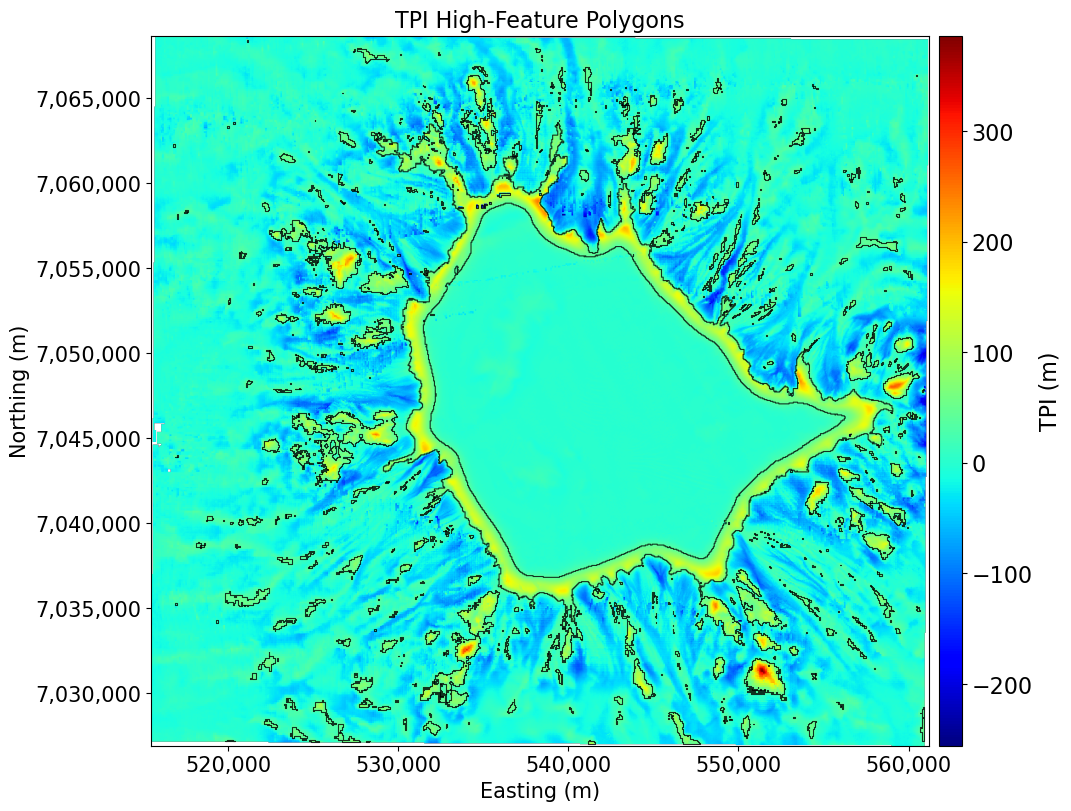

In [15]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Display TPI raster as background
im = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Overlay polygon boundaries
if len(gdf_high):
    gdf_high.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(
    "TPI High-Feature Polygons",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.1
)

cbar = fig.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "TPI (m)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

### Repeat the same workflow to visualize TPI threshold mask for low features

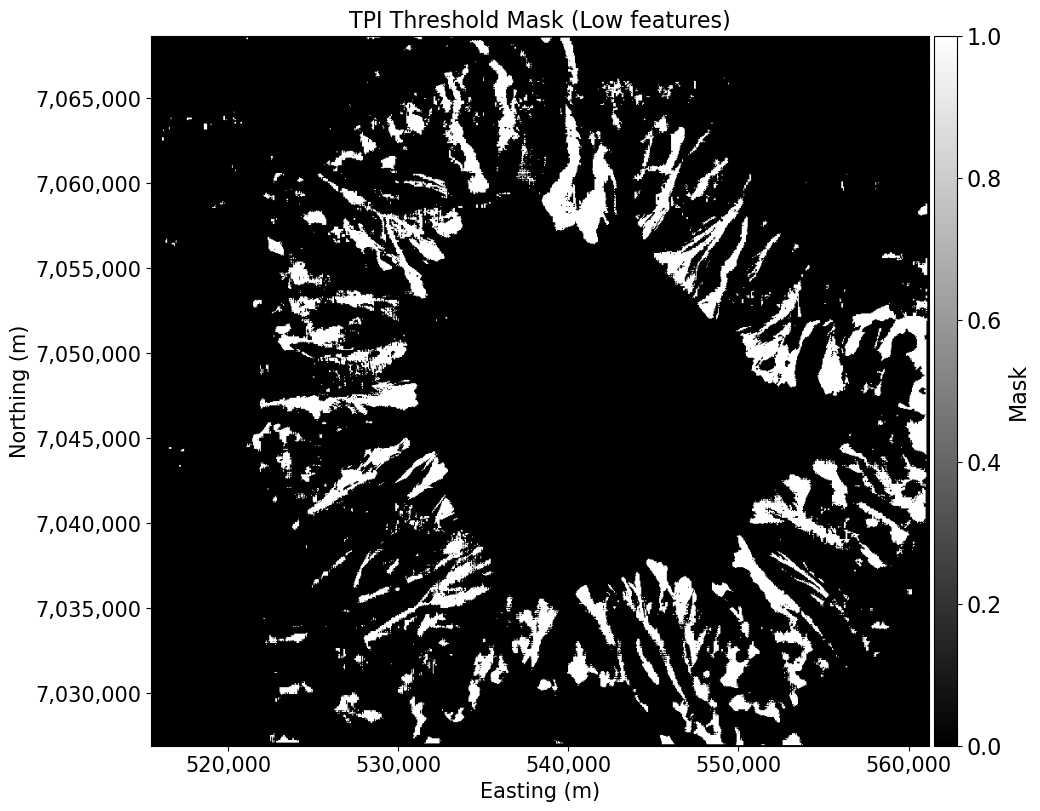

In [16]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

im_low = ax.imshow(
    mask_low.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1
)

ax.set_title(
    "TPI Threshold Mask (Low features)",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.05
)

cbar = fig.colorbar(
    im_low,
    cax=cax
)

cbar.set_label(
    "Mask",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

In [17]:
shapes_all_low = rfeatures.shapes(
    mask_low.astype(np.uint8),
    transform=transform
)

geoms_all_low = [
    shape(geom)
    for geom, val in shapes_all_low
    if val == 1
]

gdf_low = gpd.GeoDataFrame(
    geometry=geoms_all_low,
    crs=crs
)

print("Polygons before filtering:", len(gdf_low))

Polygons before filtering: 1583


In [18]:
# Define output directory and file path
out_dir = "../data"

In [19]:
# Note: This variable is defined later in the notebook. It is also present here for the purpose of saving polygons associated with this calculation
area_threshold_low = 25000.0  # approximately 10 pixels

output_path = os.path.join(
    out_dir,
    f"tpi_low_radius_{r}_area_{area_threshold_low}.gpkg"
)

# Save GeoDataFrame as GeoPackage for GIS compatibility
gdf_low.to_file(
    output_path,
    layer="features",
    driver="GPKG"
)

print(f"Saved vector file to: {output_path}")

Saved vector file to: ../data/tpi_low_radius_25_area_25000.0.gpkg


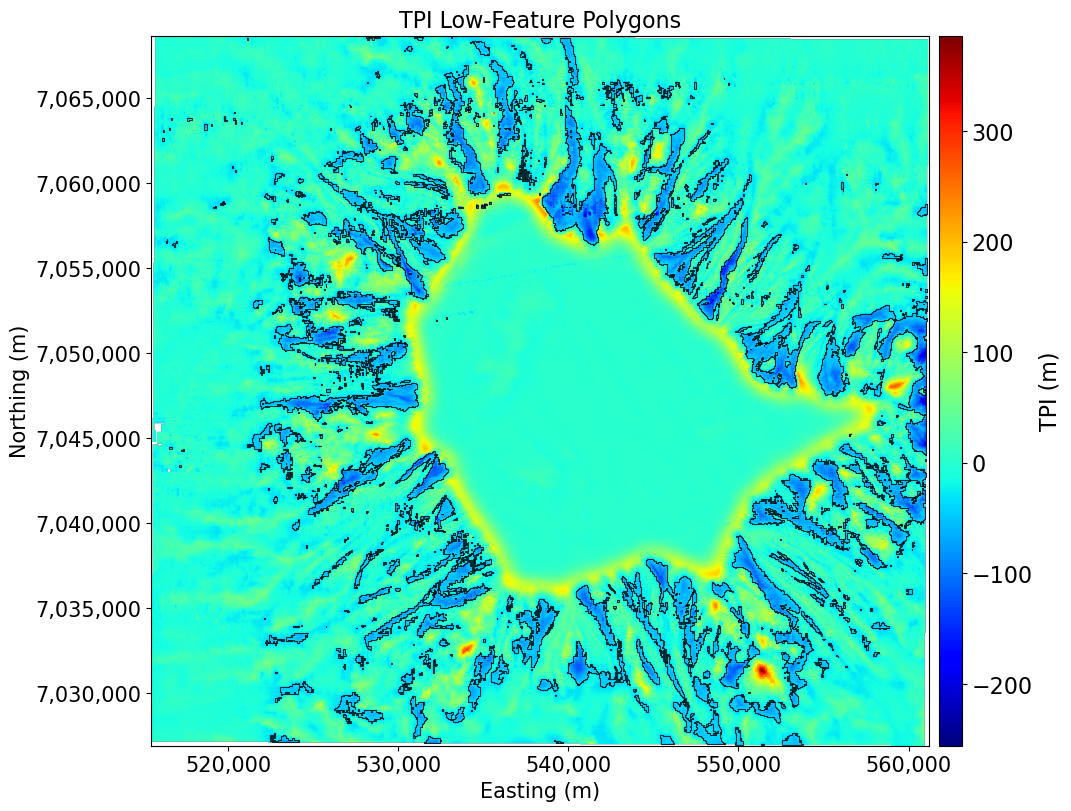

In [20]:
# Visualization 
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Display TPI raster as background
im_tpi = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Overlay LOW-feature polygon boundaries
if len(gdf_low):
    gdf_low.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(
    "TPI Low-Feature Polygons",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.1
)

cbar = fig.colorbar(
    im_tpi,
    cax=cax
)

cbar.set_label(
    "TPI (m)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

### Interpretation

This workflow completes the transition from continuous raster analysis to vector-based geomorphic mapping. Thresholding identifies statistically significant bathymetric features, while polygonization converts connected regions into discrete feature boundaries suitable for measurement, filtering, and spatial analysis.

## Selecting the Largest Features

After polygonization, the dataset may contain many polygons of different sizes.

Some polygons represent large geomorphic features, while others may be small isolated regions created by local variability in the TPI raster.

One way to reduce noise is to rank polygons by area and retain only the largest features in a process known as area threshold parameter masking. 

This approach highlights the most prominent bathymetric highs and lows in the study area and can simplify interpretation of the results.

In [21]:
# Remove small polygon artifacts generated during raster-to-vector conversion

# Minimum polygon area threshold (units depend on CRS; here ~10 pixels equivalent)
area_threshold_high = 25000.0

# Create a copy so original GeoDataFrame is preserved
gdf_high_filtered = gdf_high.copy()

# Only proceed if there are polygons present
if len(gdf_high_filtered):

    # Compute polygon areas using GeoPandas geometry area attribute
    gdf_high_filtered["area"] = gdf_high_filtered.area

    # Filter out polygons smaller than the threshold
    gdf_high_filtered = (
        gdf_high_filtered[
            gdf_high_filtered["area"] > area_threshold_high
        ].copy()
    )

# Summary Statistics 

print(
    "High-feature polygons before filtering:",
    len(gdf_high)
)

print(
    "High-feature polygons after filtering:",
    len(gdf_high_filtered)
)

print(
    "Polygons removed:",
    len(gdf_high) - len(gdf_high_filtered)
)

High-feature polygons before filtering: 1164
High-feature polygons after filtering: 245
Polygons removed: 919


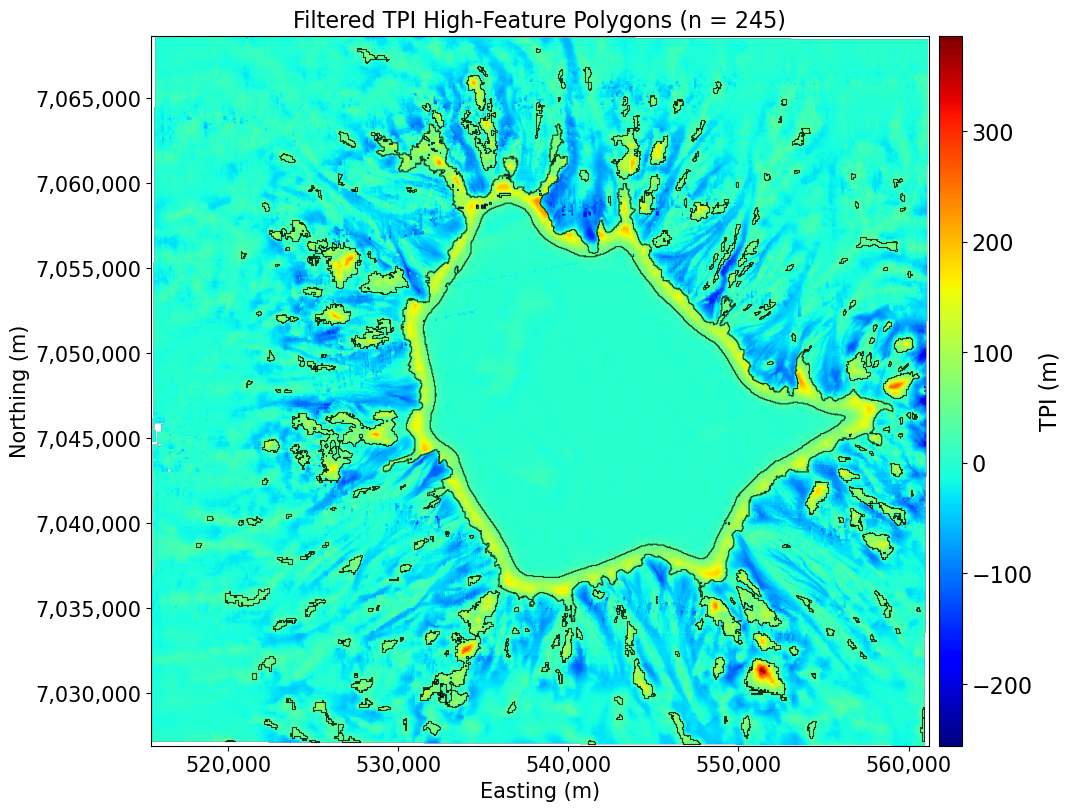

In [22]:
# Filtered High-Feature Polygon Visualization
# Displays TPI raster with filtered polygon boundaries overlaid

# Create figure and axis for map visualization
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Background raster (TPI)
# Display continuous TPI surface as background reference
im = ax.imshow(
    tpi,
    extent=extent,      # ensures correct spatial alignment
    origin="upper",
    cmap="jet"
)

# Overlay filtered polygons
# Plot only polygon boundaries (not filled geometries)
# to highlight spatial structure of high TPI features
if len(gdf_high_filtered):

    gdf_high_filtered.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

# Map formatting 
ax.set_title(
    f"Filtered TPI High-Feature Polygons (n = {len(gdf_high_filtered)})",
    fontsize=16
)

ax.set_xlabel("Easting (m)", fontsize=15)
ax.set_ylabel("Northing (m)", fontsize=15)

# Apply coordinate formatting for readability
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(axis="both", labelsize=15)

# Colorbar 
# Attach colorbar to match raster background
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("TPI (m)", fontsize=16)
cbar.ax.tick_params(labelsize=16)

plt.show()

### Repeat workflow for low features

In [23]:
# Area Filtering (Low-Feature Polygons)
# Removes small, noise-like polygons produced during raster-to-vector conversion

# Minimum polygon area threshold (approx. ~10 pixel equivalent in this raster)
area_threshold_low = 25000.0

# Create a copy of the GeoDataFrame to preserve original geometry set
gdf_low_filtered = gdf_low.copy()

# Ensure there are polygons before applying operations
if len(gdf_low_filtered):

    # Compute polygon area for each feature (based on CRS units)
    gdf_low_filtered["area"] = gdf_low_filtered.area

    # Filter out polygons smaller than the defined threshold
    gdf_low_filtered = (
        gdf_low_filtered[
            gdf_low_filtered["area"] > area_threshold_low
        ].copy()
    )

# Summary Statistics

print(
    "Low-feature polygons before filtering:",
    len(gdf_low)
)

print(
    "Low-feature polygons after filtering:",
    len(gdf_low_filtered)
)

print(
    "Polygons removed:",
    len(gdf_low) - len(gdf_low_filtered)
)

Low-feature polygons before filtering: 1583
Low-feature polygons after filtering: 296
Polygons removed: 1287


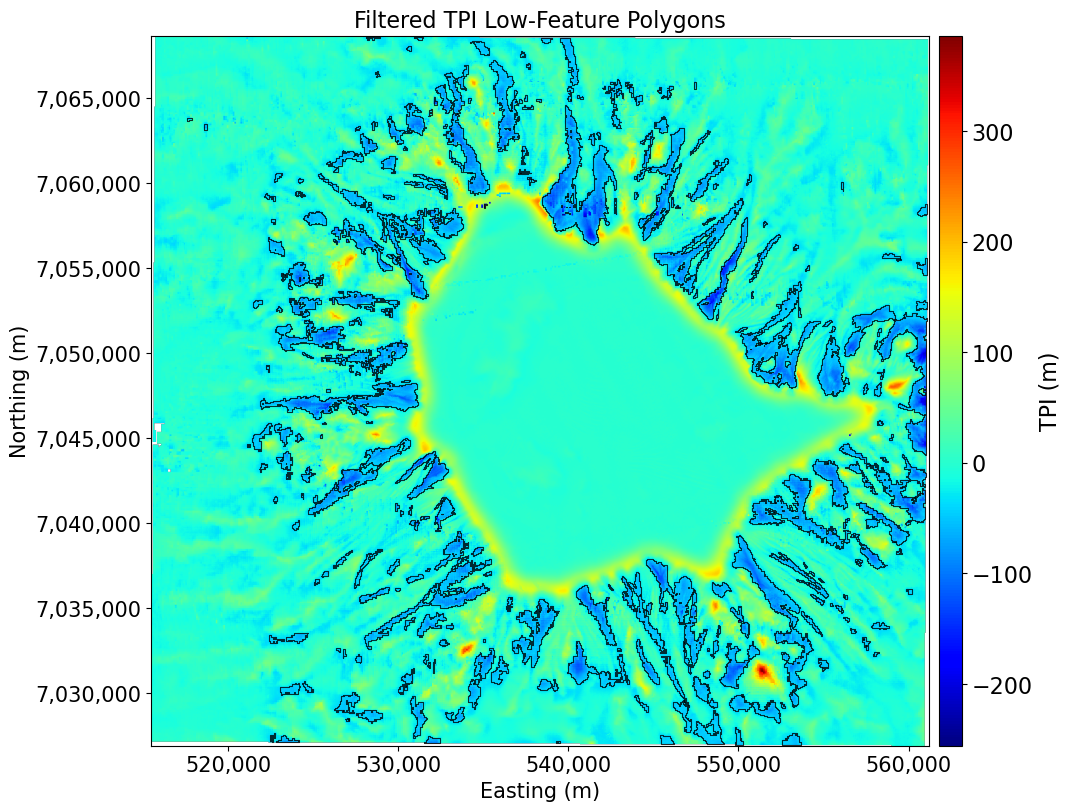

In [24]:
# Low-Feature Polygon Visualization
# Displays filtered low TPI features over the continuous TPI surface

# Create figure and axis for visualization
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Background raster (TPI)
# Show continuous TPI surface to provide spatial context for features
im_tpi = ax.imshow(
    tpi,
    extent=extent,      # ensures spatial alignment with vector data
    origin="upper",
    cmap="jet"
)

# Overlay filtered low-feature polygons
# Plot only polygon boundaries to emphasize spatial structure of low TPI features
if len(gdf_low_filtered):

    gdf_low_filtered.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

# Map formatting
ax.set_title(
    "Filtered TPI Low-Feature Polygons",
    fontsize=16
)

ax.set_xlabel("Easting (m)", fontsize=15)
ax.set_ylabel("Northing (m)", fontsize=15)

# Apply coordinate formatting for consistency across figures
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(axis="both", labelsize=15)

# Colorbar
# Add colorbar linked to raster background for reference of elevation/TPI values
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cbar = fig.colorbar(im_tpi, cax=cax)
cbar.set_label("TPI (m)", fontsize=16)
cbar.ax.tick_params(labelsize=16)

plt.show()

---

# Summary

The final output consists of bathymetric high-feature and low-feature polygons derived from the Topographic Position Index (TPI). Positive TPI values represent areas elevated relative to their surroundings, while negative values indicate local depressions. Through statistical thresholding, the most prominent topographic deviations are isolated and converted from raster-based classifications into discrete vector polygons via polygonization.

Following area filtering, small and isolated polygons are removed, leaving only the most geomorphically meaningful seabed structures. This step reduces noise introduced during raster-to-vector conversion and ensures that the resulting features represent coherent spatial patterns rather than artifacts.

Overall, this workflow provides a structured transition from continuous bathymetric data to discrete geomorphic objects that can be directly interpreted and analyzed within a GIS framework. The method closely follows the approach of Huang et al. (2023), where TPI-based segmentation is used to delineate seabed morphology across multiple spatial scales.

## Next Steps

The next step in the analysis is to incorporate Local Moran’s I (LMI), which will be used to identify spatially coherent regions that may not be captured by local elevation differences alone. Unlike TPI, which is based on local relief, LMI captures statistically significant clustering and will help refine geomorphic structures by grouping adjacent areas that behave as part of the same spatial pattern.


# References

Huang, Z., Nanson, R., McNeil, M., Wenderlich, M., Gafeira, J., Post, A. L., & Nichol, S. L. (2023). Rule-based semi-automated tools for mapping seabed morphology from bathymetry data. *Frontiers in Marine Science, 10*. https://doi.org/10.3389/fmars.2023.1236788